# TMNIST Digit Classification

Exploratory Data Analysis and Machine Learning models using the TMNIST dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = pd.read_csv('C:/Users/franc/Documents/Archivos/Facultad/Laboratorio de datos/TP - 2/Nueva carpeta/data/TMNIST_Data.csv')

dataset.head()

,names,labels,1,2,3,4,5,6,7,8,...,775,776,777,778,779,780,781,782,783,784
0,GrandHotel-Regular,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,EncodeSansCondensed-Medium,8,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Varela-Regular,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ArefRuqaa-Bold,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,KulimPark-Regular,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29900 entries, 0 to 29899
Columns: 786 entries, names to 784
dtypes: int64(785), object(1)
memory usage: 179.3+ MB


The dataset contains grayscale images of handwritten digits.
Each image has 28x28 pixels represented as 784 numerical features.

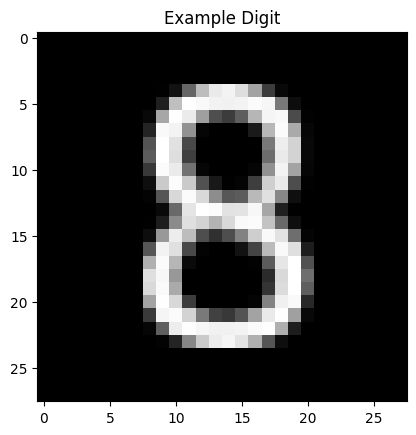

In [5]:
pixels = dataset.iloc[:, 2:]

img = np.array(pixels.iloc[1]).reshape((28,28))

plt.imshow(img, cmap='gray')
plt.title('Example Digit')
plt.show()

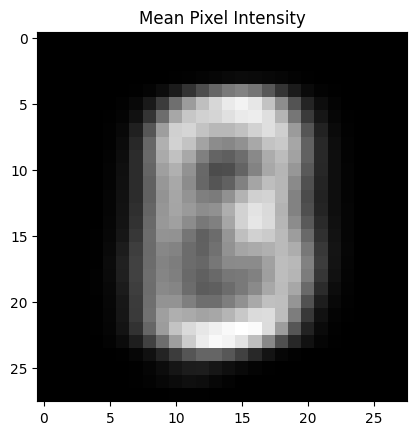

In [6]:
mean_pixels = pixels.mean()

img = np.array(mean_pixels).reshape((28,28))

plt.imshow(img, cmap='gray')

plt.title('Mean Pixel Intensity')

plt.show()

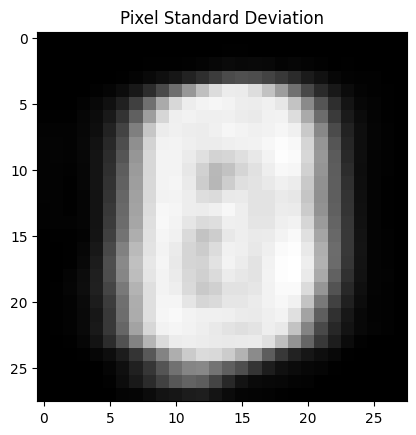

In [7]:
std_pixels = pixels.std()

img = np.array(std_pixels).reshape((28,28))

plt.imshow(img, cmap='gray')

plt.title('Pixel Standard Deviation')

plt.show()

In [8]:
def crop_image(row):

    img = np.array(row[2:]).reshape((28,28))

    return img[2:-2, 2:-2].flatten()

In [9]:
cropped = dataset.apply(crop_image, axis=1)

cropped = pd.DataFrame(cropped.tolist())

cropped['labels'] = dataset['labels']

cropped.head()

,0,1,2,3,4,5,6,7,8,9,...,567,568,569,570,571,572,573,574,575,labels
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


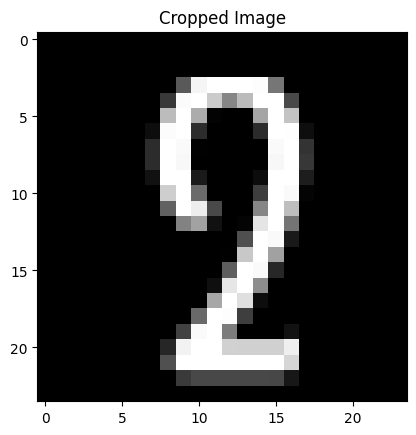

In [10]:
img = np.array(cropped.iloc[0, :-1]).reshape((24,24))

plt.imshow(img, cmap='gray')

plt.title('Cropped Image')

plt.show()

In [11]:
one_three = cropped[
    (cropped['labels'] == 1) |
    (cropped['labels'] == 3)
]